#### Import the necessary libraries

In [ ]:
import datetime
import glob
import re
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from spacepy.pycdf import CDF as cdf

from matplotlib.ticker import ScalarFormatter


# Required Functions

In [ ]:
def centers_to_corners_2d(ra_c, dec_c):
    """
    ra_c, dec_c: (H, W) center maps in degrees.
    Returns: RAcorn, DECcorn with shape (H+1, W+1) for pcolormesh.
    Uses midpoint edges and linear extrapolation at boundaries.
    """
    ra_c = np.asarray(ra_c, float)
    dec_c = np.asarray(dec_c, float)
    H, W = ra_c.shape

    # Midpoints between adjacent centers (internal edges)
    ra_i = 0.5 * (ra_c[1:, :] + ra_c[:-1, :])  # (H-1, W)
    ra_j = 0.5 * (ra_c[:, 1:] + ra_c[:, :-1])  # (H, W-1)
    dec_i = 0.5 * (dec_c[1:, :] + dec_c[:-1, :])
    dec_j = 0.5 * (dec_c[:, 1:] + dec_c[:, :-1])

    # Extrapolate outer edges along i (rows)
    ra_top = ra_c[0, :] - (ra_i[0, :] - ra_c[0, :])
    ra_bot = ra_c[-1, :] + (ra_c[-1, :] - ra_i[-1, :])
    dec_top = dec_c[0, :] - (dec_i[0, :] - dec_c[0, :])
    dec_bot = dec_c[-1, :] + (dec_c[-1, :] - dec_i[-1, :])

    # Extrapolate outer edges along j (cols)
    ra_left = ra_c[:, 0] - (ra_j[:, 0] - ra_c[:, 0])
    ra_right = ra_c[:, -1] + (ra_c[:, -1] - ra_j[:, -1])
    dec_left = dec_c[:, 0] - (dec_j[:, 0] - dec_c[:, 0])
    dec_right = dec_c[:, -1] + (dec_c[:, -1] - dec_j[:, -1])

    # Build (H+1, W+1) corners by averaging edges appropriately
    RAcorn = np.empty((H + 1, W + 1), float)
    DECcorn = np.empty((H + 1, W + 1), float)

    # Internal corners
    RAcorn[1:H, 1:W] = 0.25 * (ra_c[:-1, :-1] + ra_c[1:, :-1] + ra_c[:-1, 1:] + ra_c[1:, 1:])
    DECcorn[1:H, 1:W] = 0.25 * (dec_c[:-1, :-1] + dec_c[1:, :-1] + dec_c[:-1, 1:] + dec_c[1:, 1:])

    # Edges (average adjacent edge lines with neighbors)
    RAcorn[0, 1:W] = 0.5 * (ra_top[:-1] + ra_top[1:])
    RAcorn[-1, 1:W] = 0.5 * (ra_bot[:-1] + ra_bot[1:])
    RAcorn[1:H, 0] = 0.5 * (ra_left[:-1] + ra_left[1:])
    RAcorn[1:H, -1] = 0.5 * (ra_right[:-1] + ra_right[1:])

    DECcorn[0, 1:W] = 0.5 * (dec_top[:-1] + dec_top[1:])
    DECcorn[-1, 1:W] = 0.5 * (dec_bot[:-1] + dec_bot[1:])
    DECcorn[1:H, 0] = 0.5 * (dec_left[:-1] + dec_left[1:])
    DECcorn[1:H, -1] = 0.5 * (dec_right[:-1] + dec_right[1:])

    # Four corners (average of adjacent edges)
    RAcorn[0, 0] = 0.5 * (ra_top[0] + ra_left[0])
    RAcorn[0, -1] = 0.5 * (ra_top[-1] + ra_right[0])
    RAcorn[-1, 0] = 0.5 * (ra_bot[0] + ra_left[-1])
    RAcorn[-1, -1] = 0.5 * (ra_bot[-1] + ra_right[-1])

    DECcorn[0, 0] = 0.5 * (dec_top[0] + dec_left[0])
    DECcorn[0, -1] = 0.5 * (dec_top[-1] + dec_right[0])
    DECcorn[-1, 0] = 0.5 * (dec_bot[0] + dec_left[-1])
    DECcorn[-1, -1] = 0.5 * (dec_bot[-1] + dec_right[-1])

    return RAcorn, DECcorn


def plot_on_ra_dec(
    ax,
    ra_corners,
    dec_corners,
    data,
    title=None,
    cbar_title=None,
    time_range=None,
    vmin=None,
    vmax=None,
    norm="linear",
):
    """
    Plot data on a RA/Dec grid using pcolormesh.
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes to plot on.
    ra_corners : 2D array
        RA corner coordinates (H+1, W+1) in degrees.
    dec_corners : 2D array
        Dec corner coordinates (H+1, W+1) in degrees.
    data : 2D array
        Data values (H, W) to plot.
    title : str, optional
        Title for the plot.
    cbar_title : str, optional
        Title for the colorbar.
    time_range : list of str, optional
        List with start and end time strings for annotation.
    vmin : float, optional
        Minimum data value for color scaling.
    vmax : float, optional
        Maximum data value for color scaling.
    norm : str, optional
        Normalization type: 'linear' or 'log'.
    Returns
    -------
    pm : QuadMesh
        The pcolormesh object.
    """
    if norm == "linear":
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    elif norm == "log":
        if vmin is None:
            if np.nanmin(data) > 0:
                vmin = np.nanmin(data)
            else:
                vmin = 1e-3 * np.nanmax(data)
        if vmax is None:
            vmax = np.nanmax(data)
        norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
    else:
        norm = None
    pm = ax.pcolormesh(
        ra_corners,
        dec_corners,
        data,
        shading="auto",
        # vmin=vmin,
        # vmax=vmax,
        cmap="plasma",
        norm=norm,
    )
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title(title)

    cbar = plt.colorbar(
        pm, ax=ax, label=cbar_title, orientation="vertical", fraction=0.046, pad=0.00
    )

    # Force scientific notation with offset at the top
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    # formatter.set_powerlimits((-1, 1))  # force sci notation outside [-1e-3, 1e3]
    cbar.ax.yaxis.set_major_formatter(formatter)
    # Hide minor ticks
    cbar.ax.yaxis.set_minor_formatter(plt.NullFormatter())

    # Move the offset (×10^n) to the top of the colorbar
    cbar.ax.yaxis.get_offset_text().set(size=14)  # font size if you like
    cbar.ax.yaxis.get_offset_text().set_position((1.15, 1))
    return pm


def overlay_ra_dec_contours(ax, ra_c, dec_c, n_ra=7, n_dec=7, **kw):
    """
    Overlay RA and Dec contours on the given axes.
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes to overlay contours on.
    ra_c : 2D array
        RA center coordinates (H, W) in degrees.
    dec_c : 2D array
        Dec center coordinates (H, W) in degrees.
    n_ra : int, optional
        Number of RA contour levels. Default is 7.
    n_dec : int, optional
        Number of Dec contour levels. Default is 7.
    **kw : dict
        Additional keyword arguments for contour plotting.
    Returns
    -------
    None
    """
    ra_levels = np.linspace(np.nanmin(ra_c), np.nanmax(ra_c), n_ra)
    dec_levels = np.linspace(np.nanmin(dec_c), np.nanmax(dec_c), n_dec)
    ax.contour(
        ra_c, levels=ra_levels, colors="k", linewidths=0.5, alpha=0.4, extent=None
    )  # drawn in pixel coords for quick look
    ax.contour(dec_c, levels=dec_levels, colors="w", linewidths=0.5, alpha=0.4, extent=None)


def plot_exposure_and_counts(dat: dict, f: str):
    """
    Plot exposure maps and counts from LEXI L2 data.
    Parameters
    ----------
    dat : dict
        Dictionary containing LEXI L2 data arrays.
    f : str
        File path of the LEXI L2 data file (for title and saving).
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure with subplots.
    """

    ra_c = np.asarray(dat["ra_bin_map"][...])[0]
    dec_c = np.asarray(dat["dec_bin_map"][...])[0]
    time_range = [dat["epoch_start"][...][0], dat["epoch_end"][...][0]]

    RAcorn, DECcorn = centers_to_corners_2d(ra_c, dec_c)
    # Plot the exposure maps and counts
    fig, axs = plt.subplots(2, 3, figsize=(20, 12), constrained_layout=True)

    # Set the default font size
    mpl.rcParams.update({"font.size": 16})
    fig.suptitle(f"LEXI L2 Data from {Path(f).name}", fontsize=20)

    plot_on_ra_dec(
        axs[0, 0],
        RAcorn,
        DECcorn,
        np.asarray(dat["exposure_map"][...])[0],
        time_range=time_range,
        title="Exposure Map",
        cbar_title="Exposure Time (s)",
        norm="log",
        vmin=1e0,
        vmax=3e2,
    )
    plot_on_ra_dec(
        axs[0, 1],
        RAcorn,
        DECcorn,
        np.asarray(dat["flat_field_map"][...])[0],
        title="Flat Field Map",
        cbar_title="Normalized Counts",
        time_range=time_range,
        vmin=1e-1,
        vmax=1e0,
        norm="log",
    )
    plot_on_ra_dec(
        axs[0, 2],
        RAcorn,
        DECcorn,
        np.asarray(dat["background_map"][...])[0],
        title="Background Map",
        cbar_title="Counts/pixel",
        time_range=time_range,
        norm="log",
        vmin=1e-3,
        vmax=1e-1,
    )
    plot_on_ra_dec(
        axs[1, 0],
        RAcorn,
        DECcorn,
        np.asarray(dat["lexi_hist"][...])[0],
        time_range=time_range,
        title="Raw Counts",
        cbar_title="Counts/sec",
        norm="log",
    )
    plot_on_ra_dec(
        axs[1, 1],
        RAcorn,
        DECcorn,
        np.asarray(dat["lexi_histogram_bgnd_corrected"][...])[0],
        time_range=time_range,
        title="Background-Corrected Counts",
        cbar_title="Counts/sec",
        norm="log",
    )

    plot_on_ra_dec(
        axs[1, 2],
        RAcorn,
        DECcorn,
        np.asarray(dat["lexi_histogram_bgnd_flat_corrected"][...])[0],
        time_range=time_range,
        title="Background & Flat-Field Corrected Counts",
        cbar_title="Counts/sec",
        norm="log",
    )

    for ax in axs.flatten():
        ax.contour(RAcorn[:-1, :-1], DECcorn[:-1, :-1], ra_c, colors="c", linewidths=0.6, alpha=0.5)
        ax.contour(
            RAcorn[:-1, :-1], DECcorn[:-1, :-1], dec_c, colors="k", linewidths=0.6, alpha=0.5
        )
        ax.set_aspect("equal")

    figure_path = Path("./figures/exposure_maps/bg_corrected/from_l2/new/")
    figure_path.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        figure_path / (Path(f).stem + "_exposure_and_counts.png"),
        dpi=200,
        bbox_inches="tight",
        pad_inches=0.1,
    )
    return fig


#### Define the location of the L2 files

In [ ]:
l2_files = sorted(glob.glob("./data/L2/*.cdf"))


#### Define the start and end times for file selection

The valid time range for the L2 files is from 2025-03-16 19:00:00 to 2025-03-16 21:00:00

In [ ]:
start_time = datetime.datetime(2025, 3, 16, 19, 5)
end_time = datetime.datetime(2025, 3, 16, 19, 15)


#### Find all the files in the time range

In [6]:
# Regex to capture timestamp in filename
pattern = re.compile(r"lexi_l2_(\d{12})")

# Select files in time range
selected_files = []
for f in l2_files:
    match = pattern.search(f)
    if match:
        ts = datetime.datetime.strptime(match.group(1), "%Y%m%d%H%M")
        if start_time <= ts <= end_time:
            selected_files.append(f)

print(selected_files)


['./data/l2/lexi_l2_202503161905_V0.0.cdf', './data/l2/lexi_l2_202503161910_V0.0.cdf', './data/l2/lexi_l2_202503161915_V0.0.cdf']


In [7]:
# Print the attributes of the first file
if selected_files:
    first_file = selected_files[0]
    with cdf(first_file) as cdf_file:
        print("\nAttributes of the CDF file:")
        for attr in cdf_file.attrs:
            print(f"{attr}: {cdf_file.attrs[attr]}")
else:
    print("No files found in the specified time range.")



Attributes of the CDF file:
TITLE: LEXI> Lunar Environment Heliospheric X-ray Imager
Project: CLPS>Commercial Lunar Payload Services
Discipline: Space Physics>Magnetospheric Science
Source_name: LEXI>Lunar Environment Heliospheric X-ray Imager
Descriptor: LEXI>Lunar Environment Heliospheric X-ray Imager
Data_type: L2>RADEC_IMAGE
Data_version: 0.1
TEXT: The lunar environment heliophysics X-ray imager (LEXI) mission.
BM Walsh, et al., Space Sci. Rev., 2024
MODS: TBD
Logical_file_id: lexi_l2_202503161905_V0.0
Logical_source: lexi_l2_lexi
Logical_source_description: Lunar Environment Heliospheric X-ray Imager (LEXI)
PI_name: B. Walsh
PI_affiliation: Boston U.
Mission_group: LEXI>Lunar Environment Heliospheric X-ray Imager
Instrument_type: Imaging and Remote Sensing (Magnetosphere/Earth)
TEXT_supplement_1:  
File_naming_convention: source_datatype_descriptor_yyyyMMddHH
Acknowledgement: 
LINK_TITLE: LEXI Mission
spase_DatasetResourceID: 
Generated_by: Ramiz A. Qudsi
Rules_of_use: 
Generatio

In [8]:
# Read the first file in the list and print its variables and attributes
if selected_files:
    first_file = selected_files[0]
    with cdf(first_file) as cdf_file:
        print("Variables in the CDF file:")
        print(cdf_file.keys())
else:
    print("No files found in the specified time range.")


Variables in the CDF file:
KeysView(<CDF:
background_map: CDF_REAL4 [1, 91, 91]
dec_bin: CDF_REAL4 [1, 91]
dec_bin_map: CDF_REAL4 [1, 91, 91]
epoch_end: CDF_EPOCH [1]
epoch_start: CDF_EPOCH [1]
exposure_map: CDF_REAL4 [1, 91, 91]
flat_field_map: CDF_REAL4 [1, 91, 91]
lexi_hist: CDF_REAL4 [1, 91, 91]
lexi_histogram_bgnd_corrected: CDF_REAL4 [1, 91, 91]
lexi_histogram_bgnd_flat_corrected: CDF_REAL4 [1, 91, 91]
ra_bin: CDF_REAL4 [1, 91]
ra_bin_map: CDF_REAL4 [1, 91, 91]
>)


In [38]:
# Print the attributes of one of the keys
if selected_files:
    first_file = selected_files[0]
    with cdf(first_file) as cdf_file:
        print("\nAttributes of the 'lexi_hist' variable:")
        for attr in cdf_file["lexi_hist"].attrs:
            print(f"{attr}: {cdf_file['lexi_hist'].attrs[attr]}")
else:
    print("No files found in the specified time range.")



Attributes of the 'lexi_hist' variable:
FIELDNAM: LEXI counts at bin centers
VALIDMIN: 0.0
VALIDMAX: 1000000.0
SCALEMIN: 0.0
SCALEMAX: 100000.0
LABLAXIS: Counts/sec
UNITS: counts/sec
VAR_TYPE: data
FORMAT: f12.3
FILLVAL: -9.999999848243207e+30
DEPEND_0: epoch_start
DEPEND_1: ra_bin
DEPEND_2: dec_bin
DICT_KEY: image>lexi_hist
CATDESC: LEXI counts per (RA, Dec) pixel per second.
DISPLAY_TYPE: image
VAR_NOTES:  LEXI counts, background not subtracted, flat field not applied.


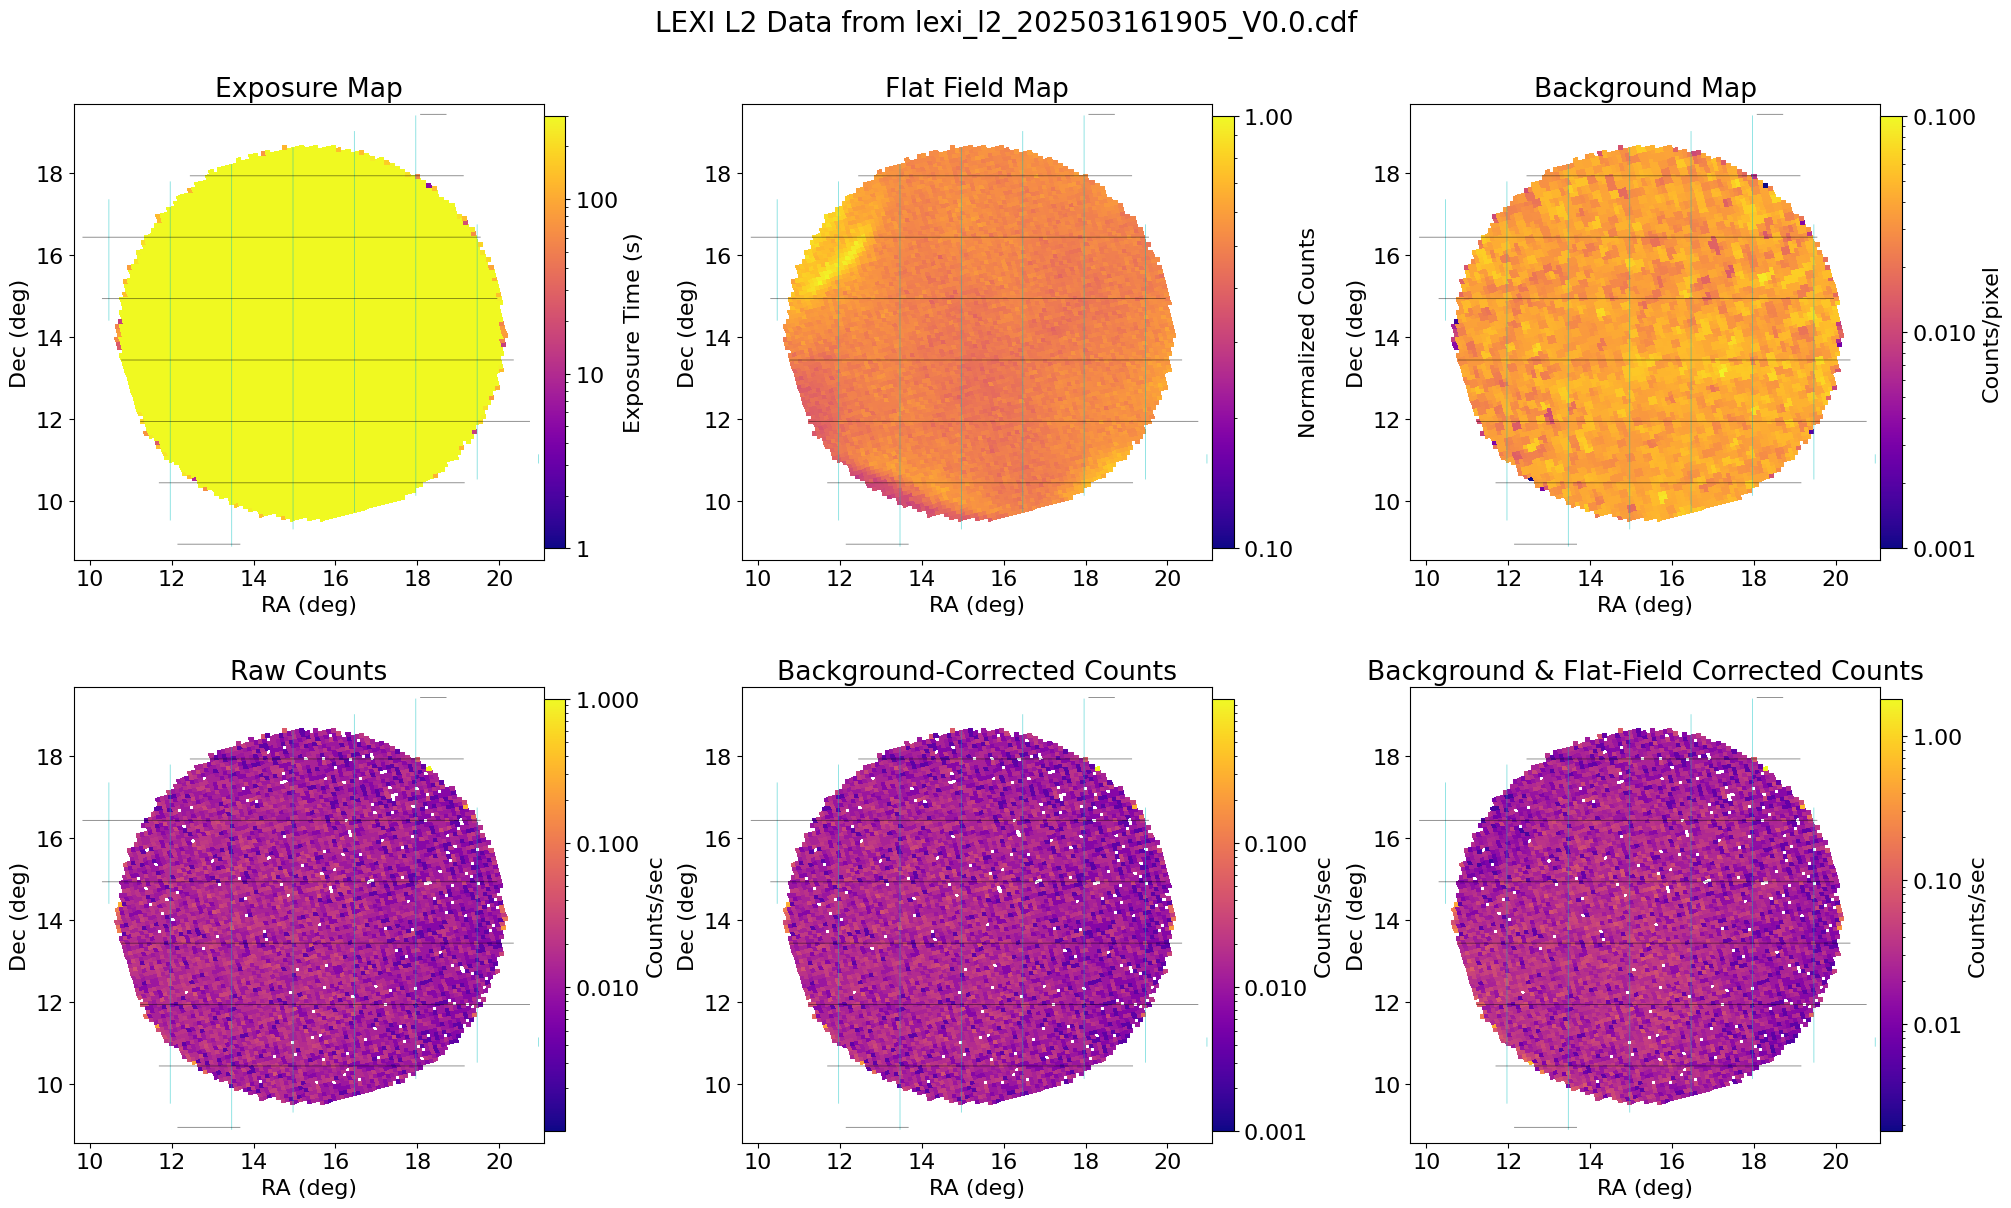

In [12]:
# Read the data from the first file
dat = cdf(selected_files[-1])
# Make a default plot
fig = plot_exposure_and_counts(dat=dat, f=selected_files[0])


In [10]:
# Print out the raw_counts variable
print(dat["lexi_hist"][...])


[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
